In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense,Input
from keras.optimizers import SGD
from keras.losses import BinaryCrossentropy

# Hyperparameters
from keras.initializers import HeNormal
from keras.layers import BatchNormalization, Dropout

from keras.callbacks import EarlyStopping, ModelCheckpoint

In [ ]:
# Load the breast cancer dataset
data = load_breast_cancer()

In [ ]:
# Display the features (data) from the dataset
data["data"]

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]])

In [ ]:
# Display the target (labels) from the dataset
data['target']

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [ ]:
# Display the shape of the target array
data['target'].shape

(569,)

In [ ]:
# Display the shape of the data array
data['data'].shape

(569, 30)

In [ ]:
# to_categorical is used to convert class labels into one-hot encoded vectors, which many neural networks in Keras require when performing multi-class classification. Also the loss function expects one-hot encoded labels.
# Prediction: [0.1, 0.2, 0.7] Actual: [0, 0, 1]
#The loss function calculates the difference between these vectors.

# Convert the target labels to one-hot encoded format
y_cat = to_categorical(data['target'])

In [ ]:
# Display the one-hot encoded target labels
y_cat

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       ...,
       [1., 0.],
       [1., 0.],
       [0., 1.]])

In [ ]:
# Split the data into training and testing sets (80% train, 20% test)
x_train, x_test, y_train, y_test = train_test_split(data['data'], y_cat, test_size = 0.2)

In [ ]:
# Display the shapes of the training and testing data and labels
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((455, 30), (114, 30), (455, 2), (114, 2))

In [ ]:
# Sequential means the neural network layers are stacked one after another in order.
# Input → Hidden Layer 1 → Hidden Layer 2 → Output Layer It is called sequential because data flows sequentially through the layers.
# Building the architecture for Neural Network

# Initialize a sequential model
model = Sequential()

# 3 ways to inform the input layer X-features
#  model.add(Input(shape=(8,)))
#  model.add(Input(shape=(df.shape[1]-1,))) # from df before the X & Y split
#  model.add(Input(shape=(X.shape[1],))) # after X and Y

# Add the input layer, specifying the shape of the input features
model.add(Input(shape = (x_train.shape[1],)))

#If input layer is not explicitly defined then you have to provide input shape in first hidden layer
#model.add(Dense(10,input_shape = (x_train.shape[1],),activation='sigmoid'))

# Add the first hidden layer with 32 units and sigmoid activation
model.add(Dense(32,activation = 'sigmoid',name='Hidden_Layer_1'))

# Add the second hidden layer with 16 units and sigmoid activation
model.add(Dense(16,activation = 'sigmoid', name="Hidden_Layer_2"))

# Add the output layer with a number of units equal to the number of output classes and softmax activation
model.add(Dense(y_train.shape[1],activation = 'softmax', name="Output_Layer"))

In [ ]:
# Install the keras_visualizer library
!pip install keras_visualizer

In [ ]:
# Import the keras_visualizer library
import keras_visualizer

# Visualize the Keras model and save it as a PNG file
keras_visualizer.visualizer(model,file_name='Modelpic',file_format='png')

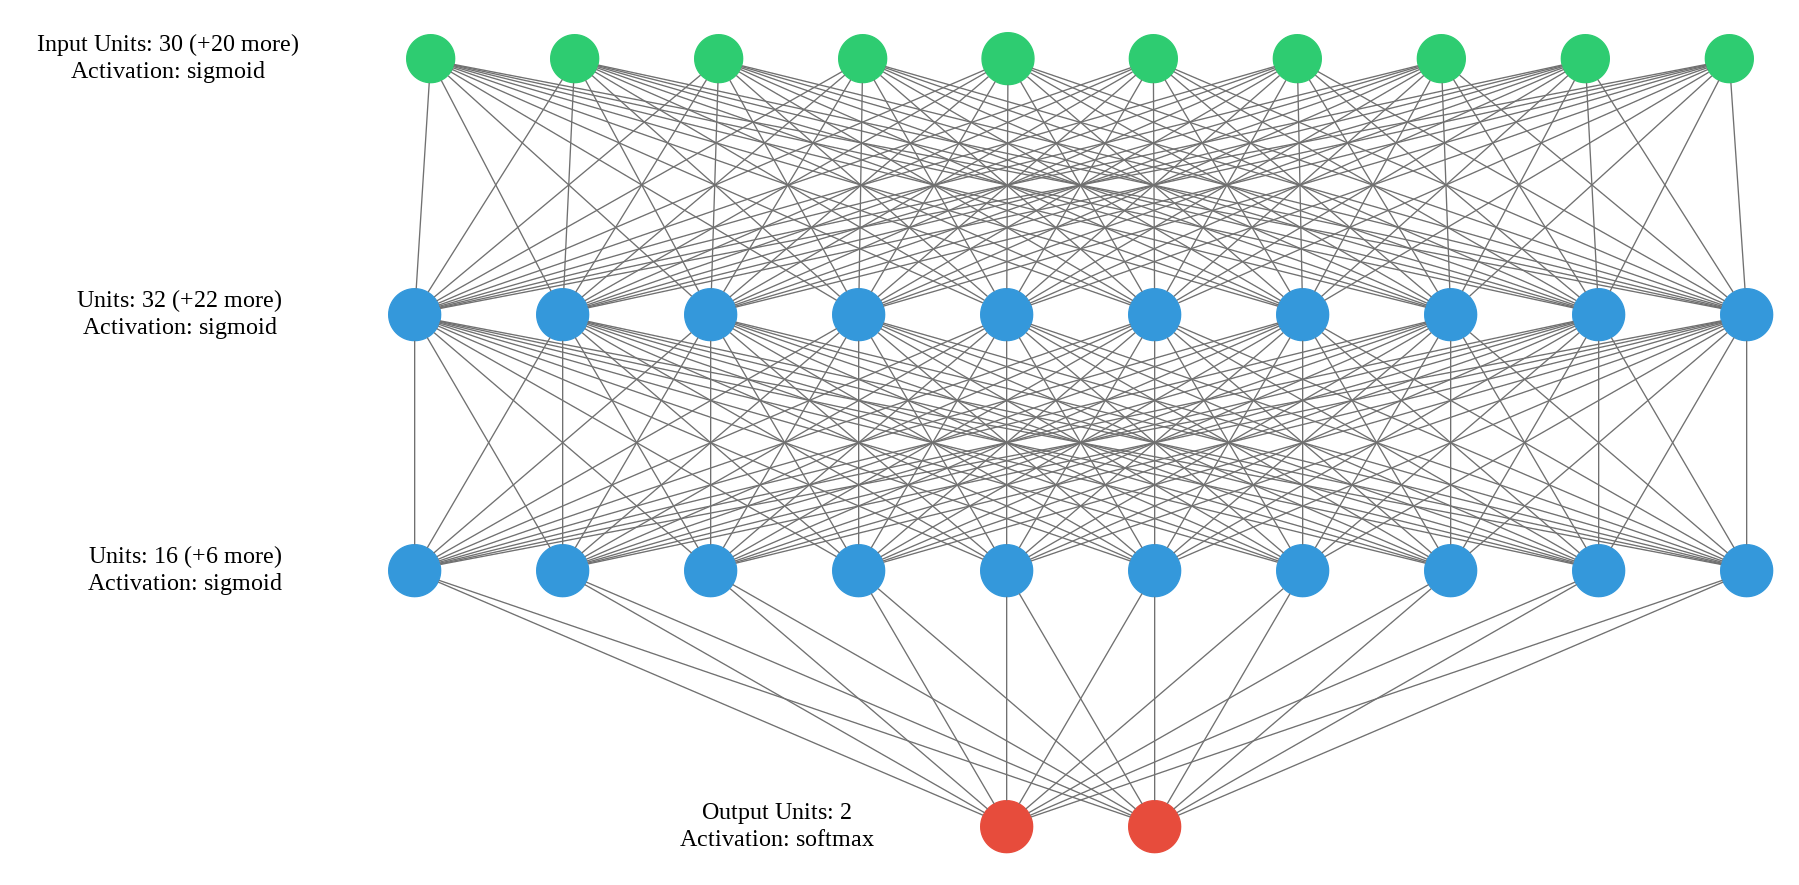

In [ ]:
# Import necessary modules for displaying images in IPython
from IPython.display import Image, display

# Display the saved model visualization image
display(Image('Modelpic.png'))

In [ ]:
# Initialize the Stochastic Gradient Descent (SGD) optimizer
sgd_optimizer = SGD()

# Initialize the Binary Crossentropy loss function
binary_loss = BinaryCrossentropy()

# Compile the model with the specified optimizer, loss function, and metrics
model.compile(optimizer = sgd_optimizer, loss = binary_loss, metrics = ['accuracy'])

In [ ]:
# Display a summary of the model's architecture, including layer names, output shapes, and number of parameters
model.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)          │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,554 (6.07 KB)

 Trainable params: 1,554 (6.07 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model using the training data, for a specified number of epochs, batch size, and validation data
history = model.fit(x_train, y_train, epochs=200, batch_size=100, validation_data=(x_test, y_test) ,verbose=1)

Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.6220 - loss: 0.8243 - val_accuracy: 0.6491 - val_loss: 0.7885
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6220 - loss: 0.7898 - val_accuracy: 0.6491 - val_loss: 0.7704
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6220 - loss: 0.7743 - val_accuracy: 0.6491 - val_loss: 0.7582
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6220 - loss: 0.7640 - val_accuracy: 0.6491 - val_loss: 0.7487
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6220 - loss: 0.7551 - val_accuracy: 0.6491 - val_loss: 0.7404
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6220 - loss: 0.7469 - val_accuracy: 0.6491 - val_loss: 0.7321
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6220 - loss: 0.7396 - val_accuracy: 0.6491 - val_loss: 0.7248
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - accuracy: 0.6220 - loss: 0.7328 - val_accuracy: 0.6491 - val_loss:

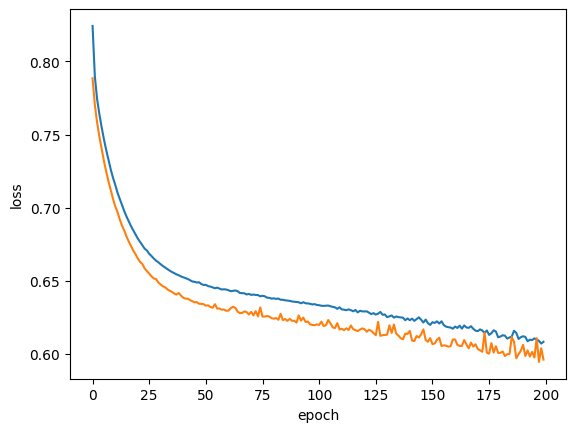

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history):
  # Plot the training loss over epochs
  plt.plot(history.history['loss'], label='train Loss')
  # Plot the validation loss over epochs
  plt.plot(history.history['val_loss'], label='val Loss')

  # Set the x-axis label
  plt.xlabel('epoch')
  # Set the y-axis label
  plt.ylabel('loss')

plot_history(history)

In [ ]:
# Initialize the Binary Crossentropy loss function
binary_loss = BinaryCrossentropy()

# Compile the model with the Adam optimizer, binary crossentropy loss, and accuracy metric
model.compile(optimizer = 'adam', loss = binary_loss, metrics = ['accuracy'])

In [ ]:
# Train the model with the updated Adam optimizer, for a specified number of epochs, batch size, and validation data
history1 = model.fit(x_train, y_train, epochs=200, batch_size=100, validation_data=(x_test, y_test) ,verbose=1)

Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.6220 - loss: 0.6067 - val_accuracy: 0.6491 - val_loss: 0.5925
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6220 - loss: 0.6024 - val_accuracy: 0.6491 - val_loss: 0.5904
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6220 - loss: 0.5999 - val_accuracy: 0.6491 - val_loss: 0.5879
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6220 - loss: 0.5974 - val_accuracy: 0.6491 - val_loss: 0.5854
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6220 - loss: 0.5944 - val_accuracy: 0.6491 - val_loss: 0.5823
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6220 - loss: 0.5914 - val_accuracy: 0.6491 - val_loss: 0.5795
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6220 - loss: 0.5880 - val_accuracy: 0.6491 - val_loss: 0.5758
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6220 - loss: 0.5843 - val_accuracy: 0.6491 - val_loss:

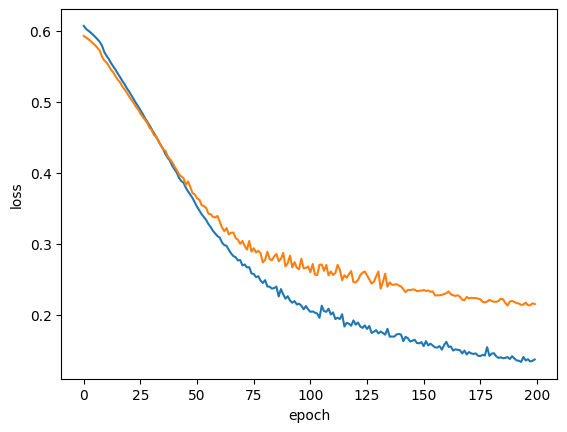

In [ ]:
plot_history(history1)

In [ ]:
# Non Saturating Activation Function

# Initialize a new sequential model
model = Sequential()

# Add the input layer, specifying the shape of the input features
model.add(Input(shape = (x_train.shape[1],)))

# Add the first hidden layer with 32 units and ReLU activation
model.add(Dense(32,activation = 'relu',name='Hidden_Layer_1'))

# Add the second hidden layer with 16 units and ReLU activation
model.add(Dense(16,activation = 'relu', name="Hidden_Layer_2"))

# Add the output layer with a number of units equal to the number of output classes and sigmoid activation
model.add(Dense(y_train.shape[1],activation = 'sigmoid', name="Output_Layer"))

In [ ]:
# Compile the model with the Adam optimizer, binary crossentropy loss, and accuracy metric
model.compile(optimizer = 'adam', loss='binary_crossentropy', metrics = ['accuracy'])

# Train the model with the updated architecture, for a specified number of epochs, batch size, and validation data
history2 = model.fit(x_train, y_train, epochs=200, batch_size=100, validation_data=(x_test, y_test) ,verbose=1)

Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 111ms/step - accuracy: 0.3780 - loss: 29.5611 - val_accuracy: 0.3509 - val_loss: 21.3778
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.3780 - loss: 16.1691 - val_accuracy: 0.3509 - val_loss: 8.4651
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4571 - loss: 5.3737 - val_accuracy: 0.8509 - val_loss: 3.7604
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7692 - loss: 3.7190 - val_accuracy: 0.7193 - val_loss: 2.9570
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7385 - loss: 2.7480 - val_accuracy: 0.8509 - val_loss: 1.2256
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8220 - loss: 1.2377 - val_accuracy: 0.6579 - val_loss: 1.3395
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6505 - loss: 1.2311 - val_accuracy: 0.8246 - val_loss: 0.9242
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8681 - loss: 0.7259 - val_accuracy: 0.8684 - val_l

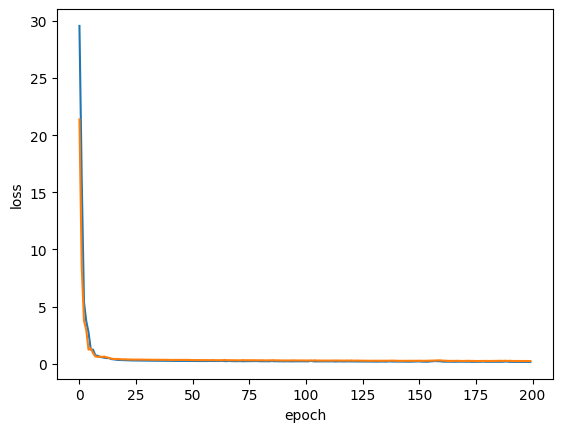

In [ ]:
plot_history(history2)

In [ ]:
# Install the scikeras library
!pip install scikeras

In [ ]:
# Proper Initialization of Weights
# Initialize the HeNormal initializer for kernel weights
initializer = HeNormal()

model = Sequential()

# Add the input layer, specifying the shape of the input features
model.add(Input(shape = (x_train.shape[1],)))

# Add the first hidden layer with HeNormal kernel initializer, ReLU activation
model.add(Dense(32,kernel_initializer = initializer, activation = 'relu',name='Hidden_Layer_1'))

# Add the second hidden layer with HeNormal kernel initializer, ReLU activation
model.add(Dense(16,kernel_initializer = initializer,activation = 'relu', name="Hidden_Layer_2"))

# Add the output layer with HeNormal kernel initializer, sigmoid activation
model.add(Dense(y_train.shape[1],kernel_initializer = initializer, activation = 'sigmoid', name="Output_Layer"))

# Compile the model with the Adam optimizer, binary crossentropy loss, and accuracy metric
model.compile(optimizer = 'adam', loss='binary_crossentropy', metrics = ['accuracy'])

# Train the model with the updated architecture, for a specified number of epochs, batch size, and validation data
history3 = model.fit(x_train, y_train, epochs=200, batch_size=100, validation_data=(x_test, y_test) ,verbose=1)

Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.3780 - loss: 76.1421 - val_accuracy: 0.3509 - val_loss: 65.3697
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.3780 - loss: 64.5201 - val_accuracy: 0.3509 - val_loss: 55.3968
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.3780 - loss: 53.5146 - val_accuracy: 0.3509 - val_loss: 45.9729
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.3780 - loss: 42.8893 - val_accuracy: 0.3509 - val_loss: 36.6982
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.3780 - loss: 33.6933 - val_accuracy: 0.3509 - val_loss: 29.9968
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.3780 - loss: 27.3884 - val_accuracy: 0.3509 - val_loss: 23.9101
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.3780 - loss: 21.5967 - val_accuracy: 0.3509 - val_loss: 18.4981
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.3780 - loss: 16.4935 - val_accuracy: 0.3

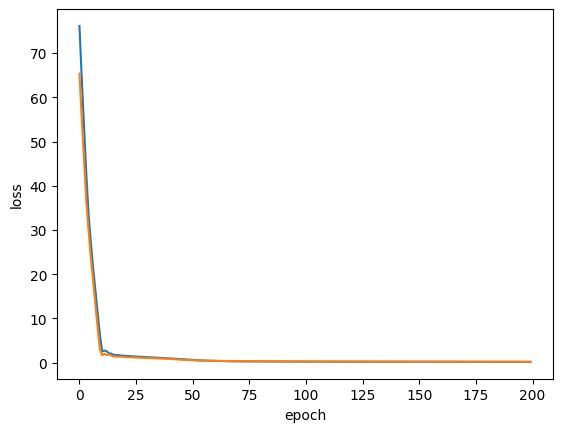

In [ ]:
plot_history(history3)

In [ ]:
# Batch Normalization

# Initialize a sequential model
model = Sequential()

# Add the input layer, specifying the shape of the input features
model.add(Input(shape = (x_train.shape[1],)))

# Add the first hidden layer with HeNormal kernel initializer, ReLU activation
model.add(Dense(32,kernel_initializer = initializer, activation = 'relu',name='Hidden_Layer_1'))
# Add Batch Normalization layer after the first hidden layer
model.add(BatchNormalization())

# Add the second hidden layer with HeNormal kernel initializer, ReLU activation
model.add(Dense(16,kernel_initializer = initializer,activation = 'relu', name="Hidden_Layer_2"))
# Add Batch Normalization layer after the second hidden layer
model.add(BatchNormalization())

# Add the output layer with HeNormal kernel initializer, sigmoid activation
model.add(Dense(y_train.shape[1],kernel_initializer = initializer, activation = 'sigmoid', name="Output_Layer"))

# Compile the model with the Adam optimizer, binary crossentropy loss, and accuracy metric
model.compile(optimizer = 'adam', loss='binary_crossentropy', metrics = ['accuracy'])

# Train the model with the updated architecture, for a specified number of epochs, batch size, and validation data
history4 = model.fit(x_train, y_train, epochs=200, batch_size=100, validation_data=(x_test, y_test) ,verbose=1)

Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 198ms/step - accuracy: 0.7077 - loss: 0.6497 - val_accuracy: 0.4123 - val_loss: 1.5097
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8484 - loss: 0.4967 - val_accuracy: 0.4561 - val_loss: 1.0493
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.8989 - loss: 0.3978 - val_accuracy: 0.5088 - val_loss: 0.8516
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.8857 - loss: 0.3577 - val_accuracy: 0.5614 - val_loss: 0.7447
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8945 - loss: 0.3415 - val_accuracy: 0.5614 - val_loss: 0.6885
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.9143 - loss: 0.3056 - val_accuracy: 0.6140 - val_loss: 0.6478
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.9165 - loss: 0.2800 - val_accuracy: 0.6316 - val_loss: 0.6210
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.9231 - loss: 0.2641 - val_accuracy: 0.6228 - val_loss

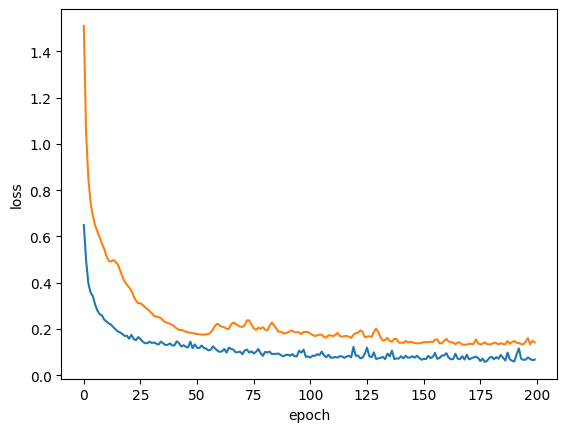

In [ ]:
plot_history(history4)

In [ ]:
# Display a summary of the model's architecture, including layer names, output shapes, and number of parameters
model.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)          │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,048 (19.72 KB)

 Trainable params: 1,650 (6.45 KB)

 Non-trainable params: 96 (384.00 B)

 Optimizer params: 3,302 (12.90 KB)

In [ ]:
# Dropout

# Initialize a sequential model
model = Sequential()

# Add the input layer, specifying the shape of the input features
model.add(Input(shape = (x_train.shape[1],)))

# Add the first hidden layer with HeNormal kernel initializer, ReLU activation
model.add(Dense(32,kernel_initializer = initializer, activation = 'relu',name='Hidden_Layer_1'))
# Add Batch Normalization layer after the first hidden layer
model.add(BatchNormalization())
# Add a Dropout layer with a dropout rate of 0.5 (50% of neurons will be randomly set to 0 during training)
model.add(Dropout(0.5))

# Add the second hidden layer with HeNormal kernel initializer, ReLU activation
model.add(Dense(16,kernel_initializer = initializer,activation = 'relu', name="Hidden_Layer_2"))
# Add Batch Normalization layer after the second hidden layer
model.add(BatchNormalization())
# Add a Dropout layer with a dropout rate of 0.5 (50% of neurons will be randomly set to 0 during training)
model.add(Dropout(0.5))

# Add the output layer with HeNormal kernel initializer, sigmoid activation
model.add(Dense(y_train.shape[1],kernel_initializer = initializer, activation = 'sigmoid', name="Output_Layer"))

# Compile the model with the Adam optimizer, binary crossentropy loss, and accuracy metric
model.compile(optimizer = 'adam', loss='binary_crossentropy', metrics = ['accuracy'])

# Train the model with the updated architecture, for a specified number of epochs, batch size, and validation data
history5 = model.fit(x_train, y_train, epochs=100, batch_size=100, validation_data=(x_test, y_test) ,verbose=1)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.5407 - loss: 0.9204 - val_accuracy: 0.4035 - val_loss: 1.6100
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6242 - loss: 0.8404 - val_accuracy: 0.4123 - val_loss: 1.1484
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6462 - loss: 0.7700 - val_accuracy: 0.4386 - val_loss: 0.9701
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7187 - loss: 0.6441 - val_accuracy: 0.4737 - val_loss: 0.8680
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7473 - loss: 0.5976 - val_accuracy: 0.4474 - val_loss: 0.7972
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7319 - loss: 0.6372 - val_accuracy: 0.4298 - val_loss: 0.7705
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7319 - loss: 0.6350 - val_accuracy: 0.4386 - val_loss: 0.7427
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7912 - loss: 0.5316 - val_accuracy: 0.4737 - val_loss:

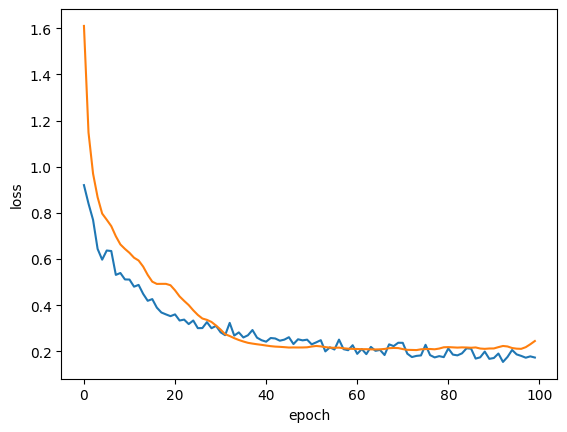

In [ ]:
plot_history(history5)

In [ ]:
# Display a summary of the model's architecture, including layer names, output shapes, and number of parameters
model.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)          │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,048 (19.72 KB)

 Trainable params: 1,650 (6.45 KB)

 Non-trainable params: 96 (384.00 B)

 Optimizer params: 3,302 (12.90 KB)

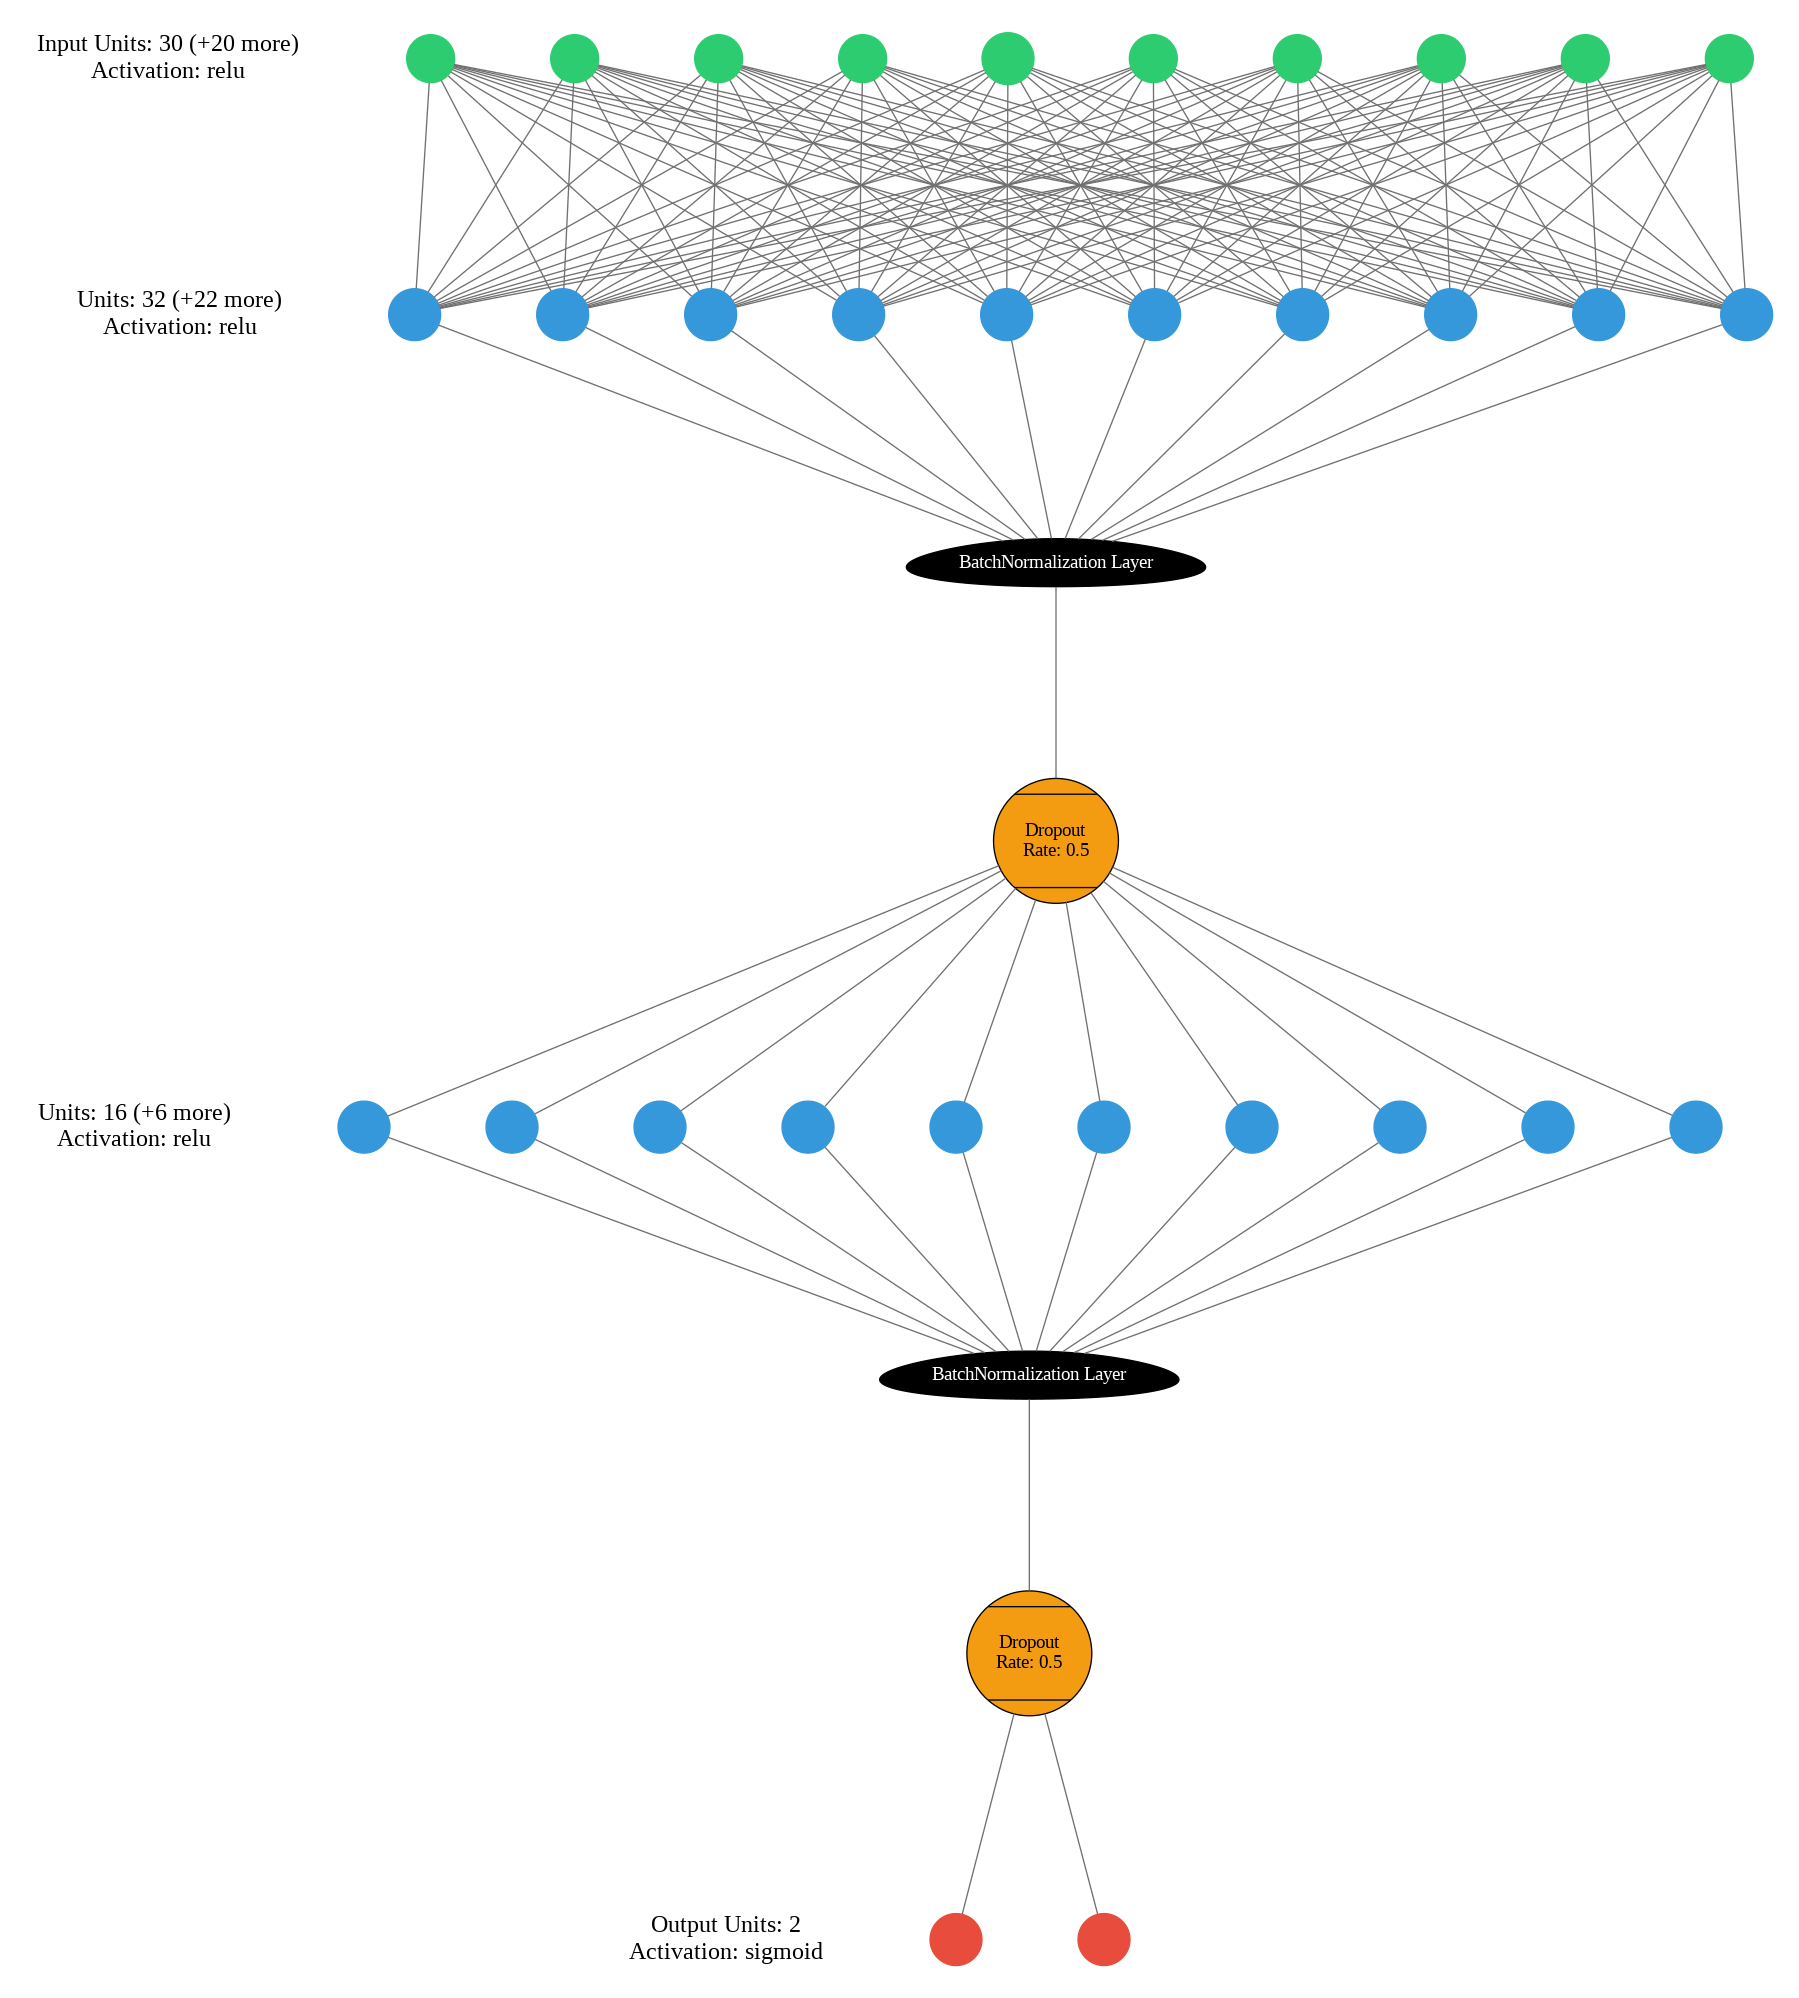

In [ ]:
# Visualize the Keras model and save it as a PNG file
keras_visualizer.visualizer(model,file_name='Modelpic1',file_format='png')

# Display the saved model visualization image
display(Image('Modelpic1.png'))

In [ ]:
#If my model doesn’t improve meaningfully for 5 rounds, stop training.
# Patience - How many epochs to wait before stopping?  If no improvement happens for 5 consecutive epochs, training stops
# Minimum improvement required to count as progress. Model must improve at least by 0.001 (0.1%)

# Define an EarlyStopping callback to monitor validation accuracy and stop training if it doesn't improve
callback = EarlyStopping(monitor='val_accuracy', min_delta = 0.001 , patience=5)

In [ ]:
# Initialize a sequential model
model = Sequential()
# Add the input layer, specifying the shape of the input features
model.add(Input(shape = (x_train.shape[1],)))

# Add the first hidden layer with HeNormal kernel initializer, ReLU activation
model.add(Dense(32,kernel_initializer = initializer, activation = 'relu',name='Hidden_Layer_1'))
# Add Batch Normalization layer after the first hidden layer
model.add(BatchNormalization())
# Add a Dropout layer with a dropout rate of 0.5
model.add(Dropout(0.5))

# Add the second hidden layer with HeNormal kernel initializer, ReLU activation
model.add(Dense(16,kernel_initializer = initializer,activation = 'relu', name="Hidden_Layer_2"))
# Add Batch Normalization layer after the second hidden layer
model.add(BatchNormalization())
# Add a Dropout layer with a dropout rate of 0.5
model.add(Dropout(0.5))

# Add the output layer with HeNormal kernel initializer, sigmoid activation
model.add(Dense(y_train.shape[1],kernel_initializer = initializer, activation = 'sigmoid', name="Output_Layer"))

# Compile the model with the Adam optimizer, binary crossentropy loss, and accuracy metric
model.compile(optimizer = 'adam', loss='binary_crossentropy', metrics = ['accuracy'])

# Train the model with the updated architecture, early stopping callback, for a specified number of epochs, batch size, and validation data
history6 = model.fit(x_train, y_train, epochs=200, batch_size=100, validation_data=(x_test, y_test) ,verbose=1, callbacks=[callback])

Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.5956 - loss: 0.9052 - val_accuracy: 0.4211 - val_loss: 1.5300
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6176 - loss: 0.8257 - val_accuracy: 0.4474 - val_loss: 1.0834
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6637 - loss: 0.7590 - val_accuracy: 0.5088 - val_loss: 0.8916
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6747 - loss: 0.6855 - val_accuracy: 0.5614 - val_loss: 0.7801
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7209 - loss: 0.6682 - val_accuracy: 0.5965 - val_loss: 0.7112
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7407 - loss: 0.5897 - val_accuracy: 0.5351 - val_loss: 0.7029
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7297 - loss: 0.6433 - val_accuracy: 0.4386 - val_loss: 0.7246
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7516 - loss: 0.5920 - val_accuracy: 0.4211 - val_loss:

In [ ]:
# Initialize He Normal (best for ReLU activation)
initializer = HeNormal()

# Create Sequential model (layer-by-layer stack)
model = Sequential()

# Input layer: defines number of input features
model.add(Input(shape=(x_train.shape[1],)))

# Hidden Layer 1
model.add(Dense(
    32,                            # Number of neurons
    activation='relu',             #ReLU activation (avoids vanishing gradient)
    kernel_initializer=initializer # He initialization for better weight scaling
))

# Batch Normalization: stabilizes learning
model.add(BatchNormalization())

# Dropout: randomly drop 50% neurons to prevent overfitting
model.add(Dropout(0.5))

# Hidden Layer 2
model.add(Dense(
    16,                              # Fewer neurons for dimensional reduction
    activation='relu',
    kernel_initializer=initializer
))

# Batch Normalization again
model.add(BatchNormalization())

# Dropout: smaller dropout (20%) for fine regularization
model.add(Dropout(0.2))

# Output Layer
model.add(Dense(
    y_train.shape[1],                # Output neurons = number of classes (2)
    activation='sigmoid'             # Sigmoid for binary classification
))

# Compile model
model.compile(
    optimizer='adam',                # Adaptive optimizer (fast + efficient)
    loss='binary_crossentropy',      # Suitable for binary classification
    metrics=['accuracy']             # Track accuracy
)

# Early Stopping callback
callback = EarlyStopping(
    monitor='val_accuracy',          # Monitor validation accuracy
    min_delta=0.001,                 # Minimum improvement required
    patience=20,                     # Wait 5 epochs before stopping
    restore_best_weights=True        # Restore best weights after stopping
)

# Train the model
history7 = model.fit(
    x_train, y_train,
    epochs=200,
    batch_size=100,
    validation_data=(x_test, y_test),
    callbacks=[callback]
)


Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.6769 - loss: 0.6474 - val_accuracy: 0.3509 - val_loss: 3.8950
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7121 - loss: 0.6196 - val_accuracy: 0.3509 - val_loss: 2.7064
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7648 - loss: 0.5628 - val_accuracy: 0.3509 - val_loss: 2.2247
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8000 - loss: 0.5076 - val_accuracy: 0.3509 - val_loss: 1.9436
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8396 - loss: 0.4723 - val_accuracy: 0.3509 - val_loss: 1.7777
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8286 - loss: 0.4850 - val_accuracy: 0.3509 - val_loss: 1.6935
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8352 - loss: 0.4533 - val_accuracy: 0.3509 - val_loss: 1.6763
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8593 - loss: 0.4182 - val_accuracy: 0.3509 - val_loss:

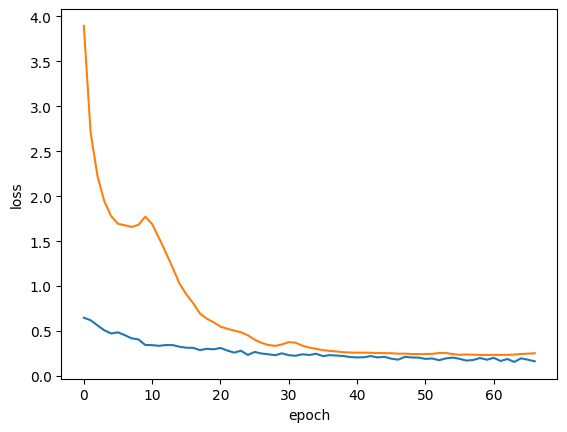

In [ ]:
plot_history(history7)